# Optional Lab: Cost Function for Logistic Regression

## Goals
In this lab, you will:
- examine the implementation and utilize the cost function for logistic regression.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Dataset

In [10]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           #(m,)

print(f"X_train: {X_train} \n Shape: {X_train.shape}, ")
print(f"y_train: {y_train} \n Shape: {y_train.shape}, ")

X_train: [[0.5 1.5]
 [1.  1. ]
 [1.5 0.5]
 [3.  0.5]
 [2.  2. ]
 [1.  2.5]] 
 Shape: (6, 2), 
y_train: [0 0 0 1 1 1] 
 Shape: (6,), 


y_train: [0 0 0 1 1 1] 
 posmask: [False False False  True  True  True] 
 negmask: [ True  True  True False False False]


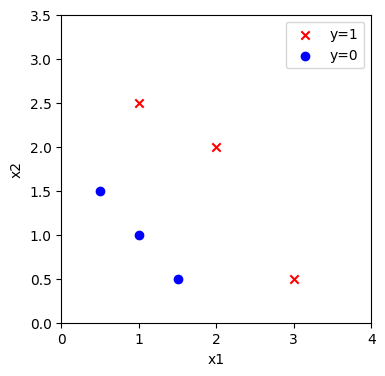

In [20]:
fig,ax = plt.subplots(1,1,figsize=(4,4))

posmask = (y_train.ravel() == 1)
negmask = (y_train.ravel() == 0)

print(f"y_train: {y_train} \n posmask: {posmask} \n negmask: {negmask}")

ax.scatter(X_train[posmask,0], X_train[posmask, 1], marker='x', c='r', label='y=1')
ax.scatter(X_train[negmask,0], X_train[negmask,1], marker='o', c='b', label='y=0')

ax.set_xlabel('x1')
ax.set_ylabel('x2')

ax.axis([0,4, 0,3.5])
ax.legend()

plt.show()



## Cost function

In a previous lab, you developed the *logistic loss* function. Recall, loss is defined to apply to one example. Here you combine the losses to form the **cost**, which includes all the examples.


Recall that for logistic regression, the cost function is of the form 

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is:

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
*  where m is the number of training examples in the data set and:
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$
 

In [21]:
def sigmoid(z):

    return 1/(1+ np.exp(-z))

In [22]:
def compute_cost(X,y,w,b):

    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)

    cost/=m

    return cost

In [24]:
w_tmp = np.array([1,1])
b_tmp = -3
print(f"Cost: {compute_cost(X_train, y_train, w_tmp, b_tmp)}")

Cost: 0.36686678640551745
